In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import het_arch
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.simplefilter("ignore")

ADF Test p-value: 0.0000


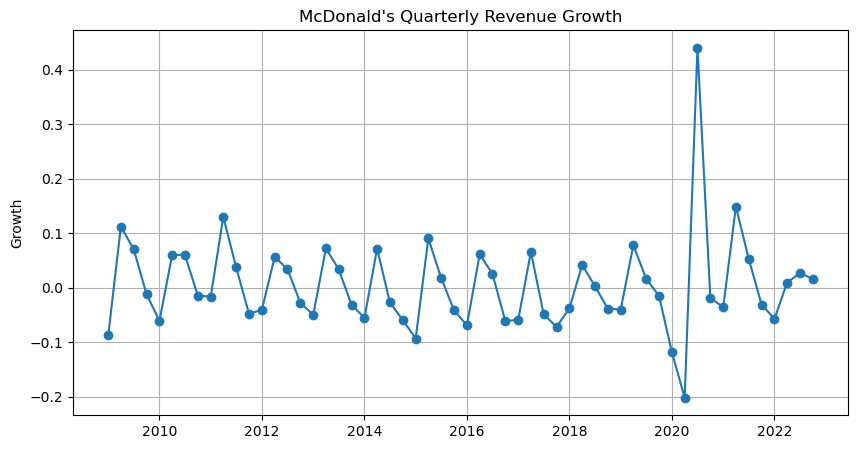

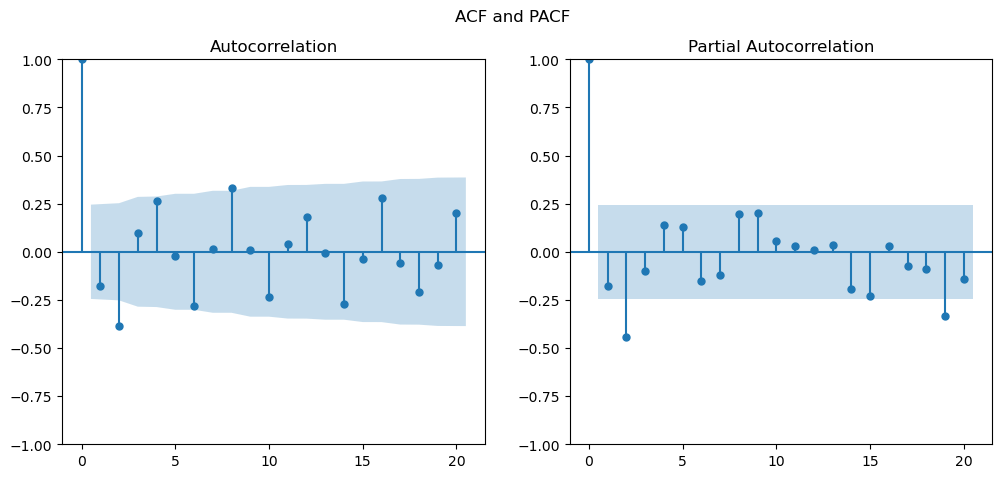

In [2]:
# Load data
df = pd.read_csv('MCD_Revenue.csv')
if 'Quarter' in df.columns:
    df['Date'] = pd.to_datetime(df['Quarter'])
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)
df['Growth'] = df['Total Revenue'].pct_change()
df.dropna(inplace=True)

#========================
# Check stationarity
#========================
def check_stationarity(series):
    result = adfuller(series.dropna())
    print(f"ADF Test p-value: {result[1]:.4f}")
    return result[1] < 0.05

# Apply differencing if needed
growth_series = df['Growth'].copy()
if not check_stationarity(growth_series):
    growth_series = growth_series.diff().dropna()
    print("Applied first-order differencing.")
    check_stationarity(growth_series)

# Split into training and testing 
test_size = 8
train = df.iloc[:-test_size]
test = df.iloc[-test_size:]

# Visualize original revenue
plt.figure(figsize=(10, 5))
plt.plot(train['Growth'], marker='o')
plt.title('McDonald\'s Quarterly Revenue Growth')
plt.ylabel('Growth')
plt.grid(True)
plt.show()

# Plot ACF and PACF for parameter selection
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plot_acf(growth_series, lags=20, ax=plt.gca())
plt.subplot(1, 2, 2)
plot_pacf(growth_series, lags=20, ax=plt.gca())
plt.suptitle('ACF and PACF')
plt.show()


In [3]:
#========================
# ARIMA Model
#========================
# Define possible values for p and q
p_values = [1, 3, 4, 5]
q_values = [1, 3, 4, 5]

# Store results for comparison
aic_values = []
bic_values = []

# Train and evaluate models for each combination of p and q
for p in p_values:
    for q in q_values:
        # Fit ARIMA model with current p, d, q (assuming d=1 for differencing)
        model = ARIMA(train['Growth'], order=(p, 1, q))
        model_fit = model.fit()
            
        # Record AIC and BIC values
        aic_values.append((p, q, model_fit.aic))
        bic_values.append((p, q, model_fit.bic))

# Convert results to DataFrames for easier comparison
aic_df = pd.DataFrame(aic_values, columns=['p', 'q', 'AIC'])
bic_df = pd.DataFrame(bic_values, columns=['p', 'q', 'BIC'])

# Find the best combination of p, q based on AIC and BIC
best_aic = aic_df.loc[aic_df['AIC'].idxmin()]
best_bic = bic_df.loc[bic_df['BIC'].idxmin()]

print("Best model based on AIC:", best_aic)
print("Best model based on BIC:", best_bic)

# Fit and summarize the best model based on AIC and BIC
best_p, best_q = best_aic['p'], best_aic['q']
best_model = ARIMA(train['Growth'], order=(best_p, 1, best_q))
best_model_fit = best_model.fit()
print(best_model_fit.summary())

# ARCH test for heteroskedasticity
arch_test_pvalue = het_arch(best_model_fit.resid)[1]
print(f"ARCH-LM test p-value: {arch_test_pvalue:.4f}")

if arch_test_pvalue < 0.05:
    print("Heteroskedasticity detected: Fitting GARCH model.")
    garch_model = arch_model(best_model_fit.resid, vol='Garch', p=1, q=1).fit(disp="off")
    garch_volatility = np.sqrt(garch_model.conditional_volatility)
else:
    print("No significant heteroskedasticity detected. GARCH not applied.")

Best model based on AIC: p        3.000000
q        3.000000
AIC   -114.236661
Name: 5, dtype: float64
Best model based on BIC: p        3.000000
q        3.000000
BIC   -100.185328
Name: 5, dtype: float64
                               SARIMAX Results                                
Dep. Variable:                 Growth   No. Observations:                   56
Model:                 ARIMA(3, 1, 3)   Log Likelihood                  64.118
Date:                Tue, 08 Apr 2025   AIC                           -114.237
Time:                        15:51:49   BIC                           -100.185
Sample:                    01-01-2009   HQIC                          -108.803
                         - 10-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L


Evaluation Metrics:
MAE  : 271.80
RMSE : 296.84
MAPE : 4.27%


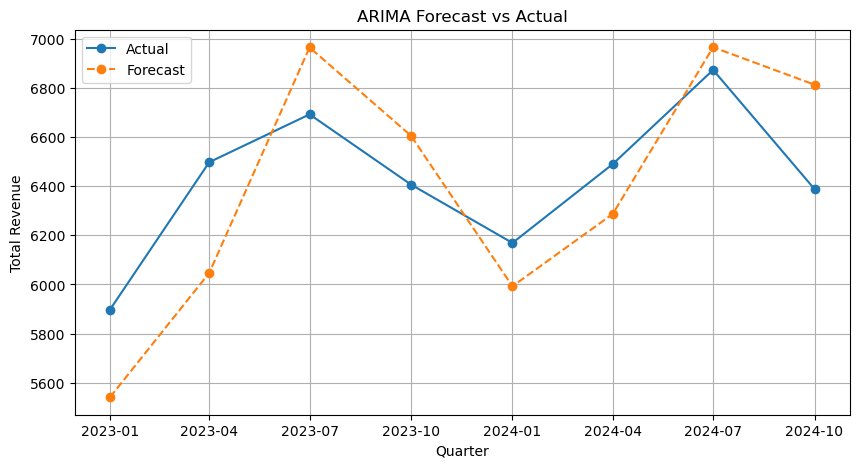

In [4]:
#========================
# Forecasting/Evaluation
#========================
# Forecasting
n_test = len(test)
forecast_growth = best_model_fit.forecast(steps=n_test)
previous_revenue = df['Total Revenue'].shift()
forecast_value = previous_revenue[-test_size:] * (1+forecast_growth)
actual = test['Total Revenue']

# Evaluation
mae = mean_absolute_error(actual, forecast_value)
rmse = np.sqrt(mean_squared_error(actual, forecast_value))
mape = np.mean(np.abs((actual - forecast_value) / actual)) * 100

print("\nEvaluation Metrics:")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

# Visualization
plt.figure(figsize=(10, 5))
plt.plot(test.index, test['Total Revenue'], label='Actual', marker='o')
plt.plot(test.index, forecast_value, label='Forecast', marker='o', linestyle='--')
plt.title('ARIMA Forecast vs Actual')
plt.xlabel('Quarter')
plt.ylabel('Total Revenue')
plt.legend()
plt.grid(True)
plt.show()


In [6]:
# Export results
forecast_growth_combined = pd.concat([best_model_fit.fittedvalues,forecast_growth])
df['Previous Revenue'] = df['Total Revenue'].shift()
df['Estimated Revenue'] = df['Previous Revenue'] * (1+forecast_growth_combined)
df.to_csv('ARIMA_Revenue.csv')